# AC Network Explore (Clean)

이 노트북은 AC 데이터로 네트워크를 만들고, BC/CC/FC 오버레이를 병합해 최종 노드 테이블을 확인/저장합니다.

진행 순서:
1. AC 읽기 + edge_df 생성
2. node_df 생성
3. 특정 성분 연결 확인
4. BC/CC/FC 로드
5. BC/CC/FC 요약 테이블 생성
6. node_df 병합 및 결측 처리
7. 결과 확인

## 1. Read AC and Build edge_df

In [1]:
import pandas as pd
from pathlib import Path

# =========================================================
# 1. 파일 읽기
#    notebook 위치: notebooks/01_ac_explore.ipynb
#    csv 위치: data/raw/OpenData_PotOpenDurIngr_AC20260312.csv
# =========================================================
base_path = Path("..") / "data" / "raw"
file_path = base_path / "OpenData_PotOpenDurIngr_AC20260312.csv"

ac_df = pd.read_csv(
    file_path,
    encoding="utf-8-sig",
    engine="python",
    on_bad_lines="skip"
)

# 불필요한 unnamed 열 제거 + 컬럼명 공백 제거
ac_df = ac_df.loc[:, ~ac_df.columns.str.contains("^Unnamed")]
ac_df.columns = ac_df.columns.str.strip()

# =========================================================
# 2. 유틸 함수
# =========================================================
def clean_text(x):
    if pd.isna(x):
        return "-"
    x = str(x).strip()
    return x if x else "-"


def choose_label(eng, kor):
    """
    영문명이 있으면 영문명 사용,
    없으면 한글명 fallback
    """
    eng = clean_text(eng)
    kor = clean_text(kor)
    return eng if eng != "-" else kor


def unique_join(series):
    """
    중복 제거 + 순서 유지 + 하나의 문자열로 결합
    """
    values = []
    for v in series:
        v = clean_text(v)
        if v != "-" and v not in values:
            values.append(v)

    if not values:
        return "-"

    return " / ".join(values)


def make_canonical_pair(row):
    """
    코드 기준으로 정렬된 pair 생성
    - 내부 식별: code
    - 표시 이름: English label
    - 보조 이름: Korean label
    """
    source_code = clean_text(row["DUR성분코드"])
    source_label_eng = choose_label(row["DUR성분명영문"], row["DUR성분명"])
    source_label_kor = clean_text(row["DUR성분명"])

    target_code = clean_text(row["병용금기DUR성분코드"])
    target_label_eng = choose_label(row["병용금기DUR성분영문명"], row["병용금기DUR성분명"])
    target_label_kor = clean_text(row["병용금기DUR성분명"])

    left = {
        "code": source_code,
        "label_eng": source_label_eng,
        "label_kor": source_label_kor
    }
    right = {
        "code": target_code,
        "label_eng": target_label_eng,
        "label_kor": target_label_kor
    }

    # 코드 기준 정렬 → A-B / B-A를 같은 edge로 묶음
    if left["code"] <= right["code"]:
        return pd.Series({
            "source_code": left["code"],
            "source_label_eng": left["label_eng"],
            "source_label_kor": left["label_kor"],
            "target_code": right["code"],
            "target_label_eng": right["label_eng"],
            "target_label_kor": right["label_kor"],
        })
    else:
        return pd.Series({
            "source_code": right["code"],
            "source_label_eng": right["label_eng"],
            "source_label_kor": right["label_kor"],
            "target_code": left["code"],
            "target_label_eng": left["label_eng"],
            "target_label_kor": left["label_kor"],
        })


def build_edge_table(ac_df):
    df = ac_df.copy()

    # 필요한 컬럼만 사용
    cols = [
        "DUR성분코드",
        "DUR성분명영문",
        "DUR성분명",
        "병용금기DUR성분코드",
        "병용금기DUR성분영문명",
        "병용금기DUR성분명",
        "금기내용"
    ]
    df = df[cols].copy()

    # 텍스트 정리
    for col in cols:
        df[col] = df[col].apply(clean_text)

    # 비어 있는 코드 제거 + 자기 자신과의 pair 제거
    df = df[
        (df["DUR성분코드"] != "-") &
        (df["병용금기DUR성분코드"] != "-") &
        (df["DUR성분코드"] != df["병용금기DUR성분코드"])
    ].copy()

    # canonical pair 생성
    pair_df = df.apply(make_canonical_pair, axis=1)
    df = pd.concat([df, pair_df], axis=1)

    # pair 기준으로 집계
    edge_df = (
        df.groupby(
            [
                "source_code",
                "source_label_eng",
                "source_label_kor",
                "target_code",
                "target_label_eng",
                "target_label_kor",
            ],
            as_index=False
        )
        .agg(
            reason=("금기내용", unique_join),
            raw_count=("금기내용", "size")
        )
        .sort_values(
            by=["raw_count", "source_label_eng", "target_label_eng"],
            ascending=[False, True, True]
        )
        .reset_index(drop=True)
    )

    return edge_df


# =========================================================
# 3. 실행
# =========================================================
edge_df = build_edge_table(ac_df)

print("raw AC row 수:", len(ac_df))
print("edge 수:", len(edge_df))
print()

print("컬럼:")
print(edge_df.columns.tolist())
print()

print("상위 10개 edge:")
display(edge_df.head(10))

print("영문 라벨 확인용:")
display(
    edge_df[
        [
            "source_label_eng",
            "source_label_kor",
            "target_label_eng",
            "target_label_kor",
            "reason",
            "raw_count"
        ]
    ].head(10)
)

# =========================================================
# 4. 특정 pair 확인 예시
# =========================================================
print("예시 pair 확인: Metformin - Iomeprol")
display(
    edge_df[
        (
            ((edge_df["source_label_eng"] == "Metformin") & (edge_df["target_label_eng"] == "Iomeprol")) |
            ((edge_df["source_label_eng"] == "Iomeprol") & (edge_df["target_label_eng"] == "Metformin"))
        )
    ]
)

# =========================================================
# 5. 저장
# =========================================================
output_path = Path("..") / "data" / "processed"
output_path.mkdir(parents=True, exist_ok=True)

save_file = output_path / "ac_edge_table_english.csv"
edge_df.to_csv(save_file, index=False, encoding="utf-8-sig")

print(f"저장 완료: {save_file}")

raw AC row 수: 1254
edge 수: 844

컬럼:
['source_code', 'source_label_eng', 'source_label_kor', 'target_code', 'target_label_eng', 'target_label_kor', 'reason', 'raw_count']

상위 10개 edge:


,source_code,source_label_eng,source_label_kor,target_code,target_label_eng,target_label_kor,reason,raw_count
0,D000364,Iomeprol,이오메프롤,D000718,Metformin,메트포르민,기능적신부전에의해유산산성증촉진,20
1,D000718,Metformin,메트포르민,D000760,Iobitridol,이오비트리돌,기능적신부전에의해유산산성증촉진,20
2,D000718,Metformin,메트포르민,D000761,Iopromide,이오프로마이드,기능적신부전에의해유산산성증촉진,20
3,D000219,Rosuvastatin,로수바스타틴,D000334,Cyclosporine,사이클로스포린,혈중농도상승및근육병증/횡문근융해증위험성증가 / 근육통|근육약화|근염|때때로횡문근변성...,20
4,D000669,Iohexol,이오헥솔,D000718,Metformin,메트포르민,기능적신부전에의해유산산성증촉진,19
5,D000165,Ioversol,이오베르솔,D000718,Metformin,메트포르민,급성신부전 / 기능적신부전에의해유산산성증촉진,19
6,D000219,Rosuvastatin,로수바스타틴,D000619,FusidicAcid,푸시딘산,횡문근융해증을포함한근육관련이상반응보고 / 횡문근융해증을포함한근육관련이상반응보 / 횡...,19
7,D000219,Rosuvastatin,로수바스타틴,D001072,Ledipasvir,레디파스비르,횡문근융해증을포함한근육병증위험증가가능,19
8,D000267,Iopamidol,이오파미돌,D000718,Metformin,메트포르민,급성신부전 / 기능적신부전에의해유산산성증촉진,18
9,D000032,IodisedOil,아이오다이즈드오일,D000718,Metformin,메트포르민,기능적신부전에의해유산산성증촉진,17


영문 라벨 확인용:


,source_label_eng,source_label_kor,target_label_eng,target_label_kor,reason,raw_count
0,Iomeprol,이오메프롤,Metformin,메트포르민,기능적신부전에의해유산산성증촉진,20
1,Metformin,메트포르민,Iobitridol,이오비트리돌,기능적신부전에의해유산산성증촉진,20
2,Metformin,메트포르민,Iopromide,이오프로마이드,기능적신부전에의해유산산성증촉진,20
3,Rosuvastatin,로수바스타틴,Cyclosporine,사이클로스포린,혈중농도상승및근육병증/횡문근융해증위험성증가 / 근육통|근육약화|근염|때때로횡문근변성...,20
4,Iohexol,이오헥솔,Metformin,메트포르민,기능적신부전에의해유산산성증촉진,19
5,Ioversol,이오베르솔,Metformin,메트포르민,급성신부전 / 기능적신부전에의해유산산성증촉진,19
6,Rosuvastatin,로수바스타틴,FusidicAcid,푸시딘산,횡문근융해증을포함한근육관련이상반응보고 / 횡문근융해증을포함한근육관련이상반응보 / 횡...,19
7,Rosuvastatin,로수바스타틴,Ledipasvir,레디파스비르,횡문근융해증을포함한근육병증위험증가가능,19
8,Iopamidol,이오파미돌,Metformin,메트포르민,급성신부전 / 기능적신부전에의해유산산성증촉진,18
9,IodisedOil,아이오다이즈드오일,Metformin,메트포르민,기능적신부전에의해유산산성증촉진,17


예시 pair 확인: Metformin - Iomeprol


,source_code,source_label_eng,source_label_kor,target_code,target_label_eng,target_label_kor,reason,raw_count
0,D000364,Iomeprol,이오메프롤,D000718,Metformin,메트포르민,기능적신부전에의해유산산성증촉진,20


저장 완료: ../data/processed/ac_edge_table_english.csv


## 2. Build node_df

In [2]:
import pandas as pd

def build_node_table(edge_df):
    """
    edge_df에서 source/target 노드 정보를 모아
    node table 생성

    최종 컬럼:
    - code
    - label_eng
    - label_kor
    - degree
    """

    # -------------------------------------------------
    # 1) source 쪽 노드 추출
    # -------------------------------------------------
    left_nodes = edge_df[
        ["source_code", "source_label_eng", "source_label_kor"]
    ].copy()

    left_nodes = left_nodes.rename(columns={
        "source_code": "code",
        "source_label_eng": "label_eng",
        "source_label_kor": "label_kor"
    })

    # -------------------------------------------------
    # 2) target 쪽 노드 추출
    # -------------------------------------------------
    right_nodes = edge_df[
        ["target_code", "target_label_eng", "target_label_kor"]
    ].copy()

    right_nodes = right_nodes.rename(columns={
        "target_code": "code",
        "target_label_eng": "label_eng",
        "target_label_kor": "label_kor"
    })

    # -------------------------------------------------
    # 3) source + target 합쳐서 unique node 만들기
    # -------------------------------------------------
    node_df = pd.concat([left_nodes, right_nodes], ignore_index=True)
    node_df = node_df.drop_duplicates().reset_index(drop=True)

    # -------------------------------------------------
    # 4) degree 계산
    #    edge 하나에 연결될 때마다 1씩 증가
    # -------------------------------------------------
    all_codes = pd.concat([
        edge_df["source_code"],
        edge_df["target_code"]
    ], ignore_index=True)

    degree_df = (
        all_codes.value_counts()
        .rename_axis("code")
        .reset_index(name="degree")
    )

    # -------------------------------------------------
    # 5) node_df에 degree 붙이기
    # -------------------------------------------------
    node_df = node_df.merge(degree_df, on="code", how="left")

    # 혹시라도 누락된 경우 대비
    node_df["degree"] = node_df["degree"].fillna(0).astype(int)

    # -------------------------------------------------
    # 6) 보기 좋게 정렬
    # -------------------------------------------------
    node_df = node_df.sort_values(
        by=["degree", "label_eng"],
        ascending=[False, True]
    ).reset_index(drop=True)

    return node_df

In [3]:
node_df = build_node_table(edge_df)

In [6]:
print("node 수:", len(node_df))
node_df.head(10)

node 수: 386


,code,label_eng,label_kor,degree
0,D000314,Rifampicin,리팜피신,45
1,D001650,Nirmatrelvir,니르마트렐비르,40
2,D000139,SelegilineHydrochloride,셀레길린염산염,40
3,D000476,Carbamazepine,카르바마제핀,29
4,D000274,Ketorolac,케토롤락,29
5,D000429,Moclobemide,모클로베미드,29
6,D000762,Itraconazole,이트라코나졸,28
7,D000595,Phenytoin,페니토인,28
8,D000447,St.JohnsWort,세인트존스워트,27
9,D000213,Pimozide,피모짓,26


In [7]:
from pathlib import Path

output_path = Path("..") / "data" / "processed"
output_path.mkdir(parents=True, exist_ok=True)

save_file = output_path / "ac_node_table_english.csv"
node_df.to_csv(save_file, index=False, encoding="utf-8-sig")

print(f"저장 완료: {save_file}")

저장 완료: ../data/processed/ac_node_table_english.csv


## 3. Inspect Specific Ingredient Links

In [8]:
rif_edges = edge_df[
    (edge_df["source_label_eng"] == "Rifampicin") |
    (edge_df["target_label_eng"] == "Rifampicin")
].copy()

rif_edges

,source_code,source_label_eng,source_label_kor,target_code,target_label_eng,target_label_kor,reason,raw_count
19,D000314,Rifampicin,리팜피신,D001563,Doravirine,도라비린,-Doravirine의혈장농도가감소하여Doravirine의치료효과가줄어들수있음 / ...,8
24,D000314,Rifampicin,리팜피신,D001699,Neratinib,네라티닙,-강력한CYP3A4유도제와의병용으로Neratinib의혈중농도감소 / -중등도CYP3...,5
29,D000161,Irinotecan,이리노테칸,D000314,Rifampicin,리팜피신,-이리노테칸활성대사물(SN-38)의혈중농도가저하되어작용감소,4
31,D000314,Rifampicin,리팜피신,D001701,Acalabrutinib,아칼라브루티닙,-강력한CYP3A유도제와의병용으로Acalabrutinib의혈중농도감소,4
32,D000314,Rifampicin,리팜피신,D000328,Bedaquiline,베다퀼린,-Bedaquiline의혈중농도와치료효과감소,4
33,D000314,Rifampicin,리팜피신,D001419,Bictegravir,빅테그라비르,-Bictegravir의혈중농도감소로인해치료효과소실및내성발현야기가능,4
34,D000314,Rifampicin,리팜피신,D001606,Brigatinib,브리가티닙,-Brigatinib의혈장농도를감소시킬수있음,4
35,D000314,Rifampicin,리팜피신,D001585,Cabozantinib,카보잔티닙,-Cabozantinib의혈장노출감소,4
36,D000314,Rifampicin,리팜피신,D001076,Ceritinib,세리티닙,-Ceritinib의혈장농도감소,4
37,D000314,Rifampicin,리팜피신,D001588,Entrectinib,엔트렉티닙,-Entrectinib의전신노출감소,4


In [9]:
rif_edges["other_drug_eng"] = rif_edges.apply(
    lambda row: row["target_label_eng"] if row["source_label_eng"] == "Rifampicin" else row["source_label_eng"],
    axis=1
)

rif_edges["other_drug_kor"] = rif_edges.apply(
    lambda row: row["target_label_kor"] if row["source_label_eng"] == "Rifampicin" else row["source_label_kor"],
    axis=1
)

rif_edges[[
    "source_label_eng",
    "target_label_eng",
    "other_drug_eng",
    "other_drug_kor",
    "reason",
    "raw_count"
]].head(20)

,source_label_eng,target_label_eng,other_drug_eng,other_drug_kor,reason,raw_count
19,Rifampicin,Doravirine,Doravirine,도라비린,-Doravirine의혈장농도가감소하여Doravirine의치료효과가줄어들수있음 / ...,8
24,Rifampicin,Neratinib,Neratinib,네라티닙,-강력한CYP3A4유도제와의병용으로Neratinib의혈중농도감소 / -중등도CYP3...,5
29,Irinotecan,Rifampicin,Irinotecan,이리노테칸,-이리노테칸활성대사물(SN-38)의혈중농도가저하되어작용감소,4
31,Rifampicin,Acalabrutinib,Acalabrutinib,아칼라브루티닙,-강력한CYP3A유도제와의병용으로Acalabrutinib의혈중농도감소,4
32,Rifampicin,Bedaquiline,Bedaquiline,베다퀼린,-Bedaquiline의혈중농도와치료효과감소,4
33,Rifampicin,Bictegravir,Bictegravir,빅테그라비르,-Bictegravir의혈중농도감소로인해치료효과소실및내성발현야기가능,4
34,Rifampicin,Brigatinib,Brigatinib,브리가티닙,-Brigatinib의혈장농도를감소시킬수있음,4
35,Rifampicin,Cabozantinib,Cabozantinib,카보잔티닙,-Cabozantinib의혈장노출감소,4
36,Rifampicin,Ceritinib,Ceritinib,세리티닙,-Ceritinib의혈장농도감소,4
37,Rifampicin,Entrectinib,Entrectinib,엔트렉티닙,-Entrectinib의전신노출감소,4


## 4. Load BC / CC / FC

In [4]:
from pathlib import Path
import pandas as pd

base_path = Path("..") / "data" / "raw"

bc_path = base_path / "OpenData_PotOpenDurIngr_BC20260312.csv"
cc_path = base_path / "OpenData_PotOpenDurIngr_CC20260312.csv"
fc_path = base_path / "OpenData_PotOpenDurIngr_FC20260312.csv"

bc_df = pd.read_csv(bc_path, encoding="utf-8-sig", engine="python", on_bad_lines="skip")
bc_df = bc_df.loc[:, ~bc_df.columns.str.contains("^Unnamed")]
bc_df.columns = bc_df.columns.str.strip()

cc_df = pd.read_csv(cc_path, encoding="utf-8-sig", engine="python", on_bad_lines="skip")
cc_df = cc_df.loc[:, ~cc_df.columns.str.contains("^Unnamed")]
cc_df.columns = cc_df.columns.str.strip()

fc_df = pd.read_csv(fc_path, encoding="utf-8-sig", engine="python", on_bad_lines="skip")
fc_df = fc_df.loc[:, ~fc_df.columns.str.contains("^Unnamed")]
fc_df.columns = fc_df.columns.str.strip()

print("BC:", bc_df.shape)
print("CC:", cc_df.shape)
print("FC:", fc_df.shape)

BC: (227, 27)
CC: (1395, 27)
FC: (107, 27)


## 5. Build BC summary table

In [5]:
bc_use = bc_df[["DUR성분코드", "연령기준", "금기내용"]].copy()

bc_use["DUR성분코드"] = bc_use["DUR성분코드"].apply(clean_text)
bc_use["연령기준"] = bc_use["연령기준"].apply(clean_text)
bc_use["금기내용"] = bc_use["금기내용"].apply(clean_text)

bc_use = bc_use[bc_use["DUR성분코드"] != "-"].copy()

bc_summary = (
    bc_use.groupby("DUR성분코드", as_index=False)
    .agg(age_rule=("연령기준", unique_join), age_reason=("금기내용", unique_join))
    .rename(columns={"DUR성분코드": "code"})
)

bc_summary["is_age_contra"] = True
bc_summary.head()

,code,age_rule,age_reason,is_age_contra
0,D000025,1세미만,-영아|유아|경련성마비또는뇌손상이있는소아에서이약의감수성증가가보고됨-신생아에투여시음식...,True
1,D000026,2세이하,안전성및유효성미확립,True
2,D000030,15세미만,안전성및유효성미확립,True
3,D000033,65세이상,65세이상에서안전성및유효성미확립.연령이높아질수록신장기능이저하되어이약이축적될수있음.,True
4,D000040,65세이상 / 12세미만,_,True


## 6. Build CC summary table

In [6]:
cc_use = cc_df[["DUR성분코드", "등급", "금기내용"]].copy()

cc_use["DUR성분코드"] = cc_use["DUR성분코드"].apply(clean_text)
cc_use["등급"] = cc_use["등급"].apply(clean_text)
cc_use["금기내용"] = cc_use["금기내용"].apply(clean_text)

cc_use = cc_use[cc_use["DUR성분코드"] != "-"].copy()

cc_summary = (
    cc_use.groupby("DUR성분코드", as_index=False)
    .agg(preg_grade=("등급", unique_join), preg_reason=("금기내용", unique_join))
    .rename(columns={"DUR성분코드": "code"})
)

cc_summary["is_preg_contra"] = True
cc_summary.head()

,code,preg_grade,preg_reason,is_preg_contra
0,D000003,2등급,임부에대한안전성미확립,True
1,D000005,2등급,정제:동물실험에서기형발생작용보고.태아의성장지체|언청이의위험등의증가|뇌성장및발달에영향...,True
2,D000006,2등급,동물실험에서고용량투여시저산소증으로인한기형유발|새끼의사망률및발달장애증가보고.신생아에서...,True
3,D000007,2등급,벤조디아제핀계약물의최기형성사례(대조군에비해높음)|신생아포유곤란|근긴장저하|졸음|황달...,True
4,D000008,2등급,임부에대한안전성미확립동물실험에서생식독성(고용량에서심장기형|폐기형|착상후유산및가역적골...,True


## 7. Build FC summary table

In [7]:
fc_use = fc_df[["DUR성분코드", "금기내용"]].copy()

fc_use["DUR성분코드"] = fc_use["DUR성분코드"].apply(clean_text)
fc_use["금기내용"] = fc_use["금기내용"].apply(clean_text)

fc_use = fc_use[fc_use["DUR성분코드"] != "-"].copy()

fc_summary = (
    fc_use.groupby("DUR성분코드", as_index=False)
    .agg(elderly_reason=("금기내용", unique_join))
    .rename(columns={"DUR성분코드": "code"})
)

fc_summary["is_elderly_caution"] = True
fc_summary.head()

,code,elderly_reason,is_elderly_caution
0,D000020,-,True
1,D000026,-,True
2,D000030,-,True
3,D000044,-,True
4,D000047,-,True


## 8. Merge overlays into node_df

In [8]:
node_overlay_df = node_df.copy()

node_overlay_df = node_overlay_df.merge(
    bc_summary[["code", "is_age_contra", "age_rule", "age_reason"]],
    on="code",
    how="left",
)

node_overlay_df = node_overlay_df.merge(
    cc_summary[["code", "is_preg_contra", "preg_grade", "preg_reason"]],
    on="code",
    how="left",
)

node_overlay_df = node_overlay_df.merge(
    fc_summary[["code", "is_elderly_caution", "elderly_reason"]],
    on="code",
    how="left",
)

node_overlay_df.head()

,code,label_eng,label_kor,degree,is_age_contra,age_rule,age_reason,is_preg_contra,preg_grade,preg_reason,is_elderly_caution,elderly_reason
0,D000314,Rifampicin,리팜피신,45,True,8세미만,흡인위험과에탐부톨로인한시력변화평가가어려울수있음,True,2등급,(Rifampicin)동물실험에서기형발생보고|(Isoniazid)동물실험(마우스)에...,NaN,NaN
1,D001650,Nirmatrelvir,니르마트렐비르,40,NaN,NaN,NaN,True,2등급,-임부에대한안전성미확립-사람에서Ritonavir의태반전달및태아노출관찰-동물실험에서골...,NaN,NaN
2,D000139,SelegilineHydrochloride,셀레길린염산염,40,NaN,NaN,NaN,True,2등급,임부에대한안전성미확립.,NaN,NaN
3,D000476,Carbamazepine,카르바마제핀,29,NaN,NaN,NaN,True,2등급,동물실험에서과량투여시태아사망률증가|결함발생등보고.간질여성의자식에이분척추및기타선천성기...,NaN,NaN
4,D000274,Ketorolac,케토롤락,29,True,16세이하 / 2세미만,안전성및유효성미확립,True,2등급,임부에대한안전성미확립.임신말기에투여시태아의동맥관조기폐쇄가능성.동물실험에서난산발생빈도...,NaN,NaN


## 9. Fill missing values

In [9]:
bool_cols = ["is_age_contra", "is_preg_contra", "is_elderly_caution"]
text_cols = ["age_rule", "age_reason", "preg_grade", "preg_reason", "elderly_reason"]

for col in bool_cols:
    node_overlay_df[col] = node_overlay_df[col].fillna(False).astype(bool)

for col in text_cols:
    node_overlay_df[col] = node_overlay_df[col].fillna("-")

node_overlay_df.head()

/var/folders/04/rs7rc_n15rl_bkvq74vv7l2m0000gn/T/ipykernel_37974/3138845312.py:5: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  node_overlay_df[col] = node_overlay_df[col].fillna(False).astype(bool)
/var/folders/04/rs7rc_n15rl_bkvq74vv7l2m0000gn/T/ipykernel_37974/3138845312.py:5: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  node_overlay_df[col] = node_overlay_df[col].fillna(False).astype(bool)
/var/folders/04/rs7rc_n15rl_bkvq74vv7l2m0000gn/T/ipykernel_37974/3138845312.py:5: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is dep

,code,label_eng,label_kor,degree,is_age_contra,age_rule,age_reason,is_preg_contra,preg_grade,preg_reason,is_elderly_caution,elderly_reason
0,D000314,Rifampicin,리팜피신,45,True,8세미만,흡인위험과에탐부톨로인한시력변화평가가어려울수있음,True,2등급,(Rifampicin)동물실험에서기형발생보고|(Isoniazid)동물실험(마우스)에...,False,-
1,D001650,Nirmatrelvir,니르마트렐비르,40,False,-,-,True,2등급,-임부에대한안전성미확립-사람에서Ritonavir의태반전달및태아노출관찰-동물실험에서골...,False,-
2,D000139,SelegilineHydrochloride,셀레길린염산염,40,False,-,-,True,2등급,임부에대한안전성미확립.,False,-
3,D000476,Carbamazepine,카르바마제핀,29,False,-,-,True,2등급,동물실험에서과량투여시태아사망률증가|결함발생등보고.간질여성의자식에이분척추및기타선천성기...,False,-
4,D000274,Ketorolac,케토롤락,29,True,16세이하 / 2세미만,안전성및유효성미확립,True,2등급,임부에대한안전성미확립.임신말기에투여시태아의동맥관조기폐쇄가능성.동물실험에서난산발생빈도...,False,-


## 10. Inspect results

In [16]:
print(node_overlay_df.shape)
node_overlay_df.head(10)

(386, 12)


,code,label_eng,label_kor,degree,is_age_contra,age_rule,age_reason,is_preg_contra,preg_grade,preg_reason,is_elderly_caution,elderly_reason
0,D000314,Rifampicin,리팜피신,45,True,8세미만,흡인위험과에탐부톨로인한시력변화평가가어려울수있음,True,2등급,(Rifampicin)동물실험에서기형발생보고|(Isoniazid)동물실험(마우스)에...,False,-
1,D001650,Nirmatrelvir,니르마트렐비르,40,False,-,-,True,2등급,-임부에대한안전성미확립-사람에서Ritonavir의태반전달및태아노출관찰-동물실험에서골...,False,-
2,D000139,SelegilineHydrochloride,셀레길린염산염,40,False,-,-,True,2등급,임부에대한안전성미확립.,False,-
3,D000476,Carbamazepine,카르바마제핀,29,False,-,-,True,2등급,동물실험에서과량투여시태아사망률증가|결함발생등보고.간질여성의자식에이분척추및기타선천성기...,False,-
4,D000274,Ketorolac,케토롤락,29,True,16세이하 / 2세미만,안전성및유효성미확립,True,2등급,임부에대한안전성미확립.임신말기에투여시태아의동맥관조기폐쇄가능성.동물실험에서난산발생빈도...,False,-
5,D000429,Moclobemide,모클로베미드,29,False,-,-,False,-,-,False,-
6,D000762,Itraconazole,이트라코나졸,28,False,-,-,True,2등급,임부에대한안전성미확립.동물실험에서고용량투여시태자기형발생증가|배자독성유발됨.,False,-
7,D000595,Phenytoin,페니토인,28,False,-,-,True,2등급,역학조사에서기형아(구순열|구개열|심기형)출산|태아의종창(신경아세포증)|히단토인증후군...,False,-
8,D000447,St.JohnsWort,세인트존스워트,27,False,-,-,True,2등급,(정제|액제)임부에서사용경험이충분하지않음,False,-
9,D000213,Pimozide,피모짓,26,False,-,-,True,2등급,임부에대한안전성미확립.임신3기에투여시신생아에서추체외로장애|금단증상(초조|근육긴장항진...,True,노인에서의정형항정신병약물사용은추체외로증상|항콜린성부작용등이나타나기쉬우므로신중투여


In [17]:
node_overlay_df[node_overlay_df["is_preg_contra"]].sort_values("degree", ascending=False).head(10)

,code,label_eng,label_kor,degree,is_age_contra,age_rule,age_reason,is_preg_contra,preg_grade,preg_reason,is_elderly_caution,elderly_reason
0,D000314,Rifampicin,리팜피신,45,True,8세미만,흡인위험과에탐부톨로인한시력변화평가가어려울수있음,True,2등급,(Rifampicin)동물실험에서기형발생보고|(Isoniazid)동물실험(마우스)에...,False,-
1,D001650,Nirmatrelvir,니르마트렐비르,40,False,-,-,True,2등급,-임부에대한안전성미확립-사람에서Ritonavir의태반전달및태아노출관찰-동물실험에서골...,False,-
2,D000139,SelegilineHydrochloride,셀레길린염산염,40,False,-,-,True,2등급,임부에대한안전성미확립.,False,-
3,D000476,Carbamazepine,카르바마제핀,29,False,-,-,True,2등급,동물실험에서과량투여시태아사망률증가|결함발생등보고.간질여성의자식에이분척추및기타선천성기...,False,-
4,D000274,Ketorolac,케토롤락,29,True,16세이하 / 2세미만,안전성및유효성미확립,True,2등급,임부에대한안전성미확립.임신말기에투여시태아의동맥관조기폐쇄가능성.동물실험에서난산발생빈도...,False,-
6,D000762,Itraconazole,이트라코나졸,28,False,-,-,True,2등급,임부에대한안전성미확립.동물실험에서고용량투여시태자기형발생증가|배자독성유발됨.,False,-
7,D000595,Phenytoin,페니토인,28,False,-,-,True,2등급,역학조사에서기형아(구순열|구개열|심기형)출산|태아의종창(신경아세포증)|히단토인증후군...,False,-
8,D000447,St.JohnsWort,세인트존스워트,27,False,-,-,True,2등급,(정제|액제)임부에서사용경험이충분하지않음,False,-
9,D000213,Pimozide,피모짓,26,False,-,-,True,2등급,임부에대한안전성미확립.임신3기에투여시신생아에서추체외로장애|금단증상(초조|근육긴장항진...,True,노인에서의정형항정신병약물사용은추체외로증상|항콜린성부작용등이나타나기쉬우므로신중투여
10,D000201,Dronedarone,드로네다론,25,False,-,-,True,2등급,동물실험에서기형유발.,False,-


In [18]:
node_overlay_df[node_overlay_df["is_elderly_caution"]].sort_values("degree", ascending=False).head(10)

,code,label_eng,label_kor,degree,is_age_contra,age_rule,age_reason,is_preg_contra,preg_grade,preg_reason,is_elderly_caution,elderly_reason
9,D000213,Pimozide,피모짓,26,False,-,-,True,2등급,임부에대한안전성미확립.임신3기에투여시신생아에서추체외로장애|금단증상(초조|근육긴장항진...,True,노인에서의정형항정신병약물사용은추체외로증상|항콜린성부작용등이나타나기쉬우므로신중투여
11,D000113,Haloperidol,할로페리돌,24,False,-,-,True,2등급,기형발생의심증례보고.임신말기나분만중투여시신생아에서기면|진전|과흥분성나타날수있음.임신...,True,노인에서의정형항정신병약물사용은추체외로증상|항콜린성부작용등이나타나기쉬우므로신중투여
38,D001763,Lurasidone,루라시돈,10,False,-,-,True,2등급,-임부에대한안전성미확립-임신3기동안항정신병약물에노출된신생아에서추체외로및/또는금단증상...,True,-
85,D000114,Hydroxyzine,히드록시진,5,False,-,-,True,2등급,신생아에서근육긴장저하|추체외로장애를포함한운동이상|간대성운동|중추신경계억제|신생아저산...,True,-
86,D000362,Imipramine,이미프라민,5,False,-,-,True,2등급,동물실험에서최대임상노출보다는낮은정도의전신노출수준(AUC)에서생식독성나타냄.임신말기에...,True,노인에서의삼환계항우울제사용은기립성저혈압|비틀거림|항콜린작용에의한구갈|배뇨곤란|변비|...
92,D000466,Nortriptyline,노르트립틸린,5,True,18세이하,안전성및유효성미확립,True,2등급,임부에대한안전성미확립.,True,노인에서의삼환계항우울제사용은기립성저혈압|비틀거림|항콜린작용에의한구갈|배뇨곤란|변비|...
101,D000584,Chlorpromazine,클로르프로마진,4,True,1세미만,추체외로증상특히운동장애가나타나기쉬움,True,2등급,임부에대한안전성미확립.동물실험에서태자독성(태자사망등)보고.임신중투여시신생아에서진전|...,True,노인에서의정형항정신병약물사용은추체외로증상|항콜린성부작용등이나타나기쉬우므로신중투여
122,D000173,Ziprasidone,지프라시돈,4,False,-,-,True,2등급,임부에대한안전성미확립.임신3기에투여시신생아에서추체외로장애|금단증상(초조|근육긴장항진...,True,-
96,D000030,Amisulpride,아미설프리드,4,True,15세미만,안전성및유효성미확립,True,2등급,임부에대한안전성미확립.,True,-
125,D000020,Blonanserin,블로난세린,3,False,-,-,True,2등급,임부에대한안전성미확립임신3기에투여시신생아에서추체외로장애|금단증상의위험가능성.,True,-


In [19]:
node_overlay_df[node_overlay_df["is_age_contra"]].sort_values("degree", ascending=False).head(10)

,code,label_eng,label_kor,degree,is_age_contra,age_rule,age_reason,is_preg_contra,preg_grade,preg_reason,is_elderly_caution,elderly_reason
0,D000314,Rifampicin,리팜피신,45,True,8세미만,흡인위험과에탐부톨로인한시력변화평가가어려울수있음,True,2등급,(Rifampicin)동물실험에서기형발생보고|(Isoniazid)동물실험(마우스)에...,False,-
4,D000274,Ketorolac,케토롤락,29,True,16세이하 / 2세미만,안전성및유효성미확립,True,2등급,임부에대한안전성미확립.임신말기에투여시태아의동맥관조기폐쇄가능성.동물실험에서난산발생빈도...,False,-
13,D000150,Atazanavir,아타자나비르,22,True,3개월이하,핵황달의위험나타날수있음,False,-,-,False,-
16,D000673,Cobicistat,코비시스타트,20,True,36개월미만 / 3개월미만,안전성및유효성미확립생후23-26일랫트에서사망관찰됨. / 핵황달의위험나타날수있음.,True,2등급,임부에대한안전성미확립 / 임신한여성을포함한환자들에게투여시고빌리루빈혈증이흔하게발생함 ...,False,-
25,D000419,Lovastatin,로바스타틴,14,True,20세미만,안전성및유효성미확립,True,1등급,태아발육에필수적인콜레스테롤의생합성감소가능성.,False,-
29,D000246,Sildenafil,실데나필,12,True,18세이하,_,True,1등급,(폐동맥고혈압치료시제외)여성에게사용할수없음동물실험에서착상률|수컷태자의체중감소|한배새...,False,-
30,D000181,Tadalafil,타다라필,12,True,18세미만,_,True,1등급,여성에게사용할수없음,False,-
40,D000569,Udenafil,유데나필,10,True,18세이하,_,True,1등급,여성에게사용할수없음동물실험에서골격변이|골화지연|차산자의사산|신체발육부진나타남,False,-
41,D000434,Vardenafil,바데나필,10,True,18세미만,_,True,1등급,여성에게사용할수없음동물실험에서구개안면골기형|흉골|척추|늑골의변이|차산자의신체발달지체관찰됨,False,-
52,D000279,Tacrolimus,타크로리무스,9,True,2세미만,안전성및유효성미확립,True,2등급,임부에대한안전성미확립.태아에고칼륨혈증및신기능장애나타남.동물실험에서최기형작용|유산증가...,False,-


## 11. Save overlay node table

In [20]:
output_path = Path("..") / "data" / "processed"
output_path.mkdir(parents=True, exist_ok=True)

save_file = output_path / "ac_node_table_with_overlay.csv"
node_overlay_df.to_csv(save_file, index=False, encoding="utf-8-sig")

print(f"saved: {save_file}")

saved: ../data/processed/ac_node_table_with_overlay.csv


## 12. Build NetworkX graph

In [10]:
import networkx as nx

def build_graph(edge_df, node_overlay_df):
    G = nx.Graph()

    # 1) 노드 추가
    for _, row in node_overlay_df.iterrows():
        G.add_node(
            row["code"],
            label_eng=row["label_eng"],
            label_kor=row["label_kor"],
            degree=row["degree"],
            is_age_contra=row["is_age_contra"],
            age_rule=row["age_rule"],
            age_reason=row["age_reason"],
            is_preg_contra=row["is_preg_contra"],
            preg_grade=row["preg_grade"],
            preg_reason=row["preg_reason"],
            is_elderly_caution=row["is_elderly_caution"],
            elderly_reason=row["elderly_reason"],
        )

    # 2) 엣지 추가
    for _, row in edge_df.iterrows():
        G.add_edge(
            row["source_code"],
            row["target_code"],
            reason=row["reason"],
            raw_count=row["raw_count"],
        )

    return G

In [11]:
G = build_graph(edge_df, node_overlay_df)
print(f"nodes: {G.number_of_nodes()}, edges: {G.number_of_edges()}")

nodes: 386, edges: 844


In [23]:
G.nodes["D000314"]

{'label_eng': 'Rifampicin',
 'label_kor': '리팜피신',
 'degree': 45,
 'is_age_contra': True,
 'age_rule': '8세미만',
 'age_reason': '흡인위험과에탐부톨로인한시력변화평가가어려울수있음',
 'is_preg_contra': True,
 'preg_grade': '2등급',
 'preg_reason': '(Rifampicin)동물실험에서기형발생보고|(Isoniazid)동물실험(마우스)에서태자발육장애가보고|(Pyrazinamide)임부에대한안전성미확립 / (Rifampicin)동물실험에서기형발생보고(Isoniazid)동물실험(마우스)에서태자발육장애가보고 / (Rifampicin)동물실험에서기형발생보고|(Pyrazinamide)임부에대한안전성미확립|(Isoniazid)동물실험(마우스)에서태자발육장애가보고|(Ethambutol)임부에대한안전성미확립 / 동물실험에서기형발생보고',
 'is_elderly_caution': False,
 'elderly_reason': '-'}

In [24]:
rif_neighbors = list(G.neighbors("D000314"))
rif_neighbors[:10], len(rif_neighbors)

(['D001563',
  'D001699',
  'D000161',
  'D001701',
  'D000328',
  'D001419',
  'D001606',
  'D001585',
  'D001076',
  'D001588'],
 45)

In [25]:
[
    (
        code,
        G.nodes[code]["label_eng"],
        G.nodes[code]["label_kor"]
    )
    for code in rif_neighbors[:20]
]

[('D001563', 'Doravirine', '도라비린'),
 ('D001699', 'Neratinib', '네라티닙'),
 ('D000161', 'Irinotecan', '이리노테칸'),
 ('D001701', 'Acalabrutinib', '아칼라브루티닙'),
 ('D000328', 'Bedaquiline', '베다퀼린'),
 ('D001419', 'Bictegravir', '빅테그라비르'),
 ('D001606', 'Brigatinib', '브리가티닙'),
 ('D001585', 'Cabozantinib', '카보잔티닙'),
 ('D001076', 'Ceritinib', '세리티닙'),
 ('D001588', 'Entrectinib', '엔트렉티닙'),
 ('D001589', 'Gilteritinib', '길테리티닙'),
 ('D001590', 'Ibrutinib', '이브루티닙'),
 ('D001612', 'Isavuconazonium', '이사부코나조늄'),
 ('D001711', 'Ixazomib', '익사조밉'),
 ('D001594', 'Midostaurin', '미도스타우린'),
 ('D001598', 'Ponatinib', '포나티닙'),
 ('D001818', 'Praziquantel', '프라지콴텔'),
 ('D001562', 'Ranolazine', '라놀라진'),
 ('D001418', 'Ribociclib', '리보시클립'),
 ('D000679', 'Tamoxifen', '타목시펜')]

In [26]:
rif_edges = []

for neighbor in G.neighbors("D000314"):
    edge_data = G.get_edge_data("D000314", neighbor)
    rif_edges.append({
        "neighbor_code": neighbor,
        "neighbor_eng": G.nodes[neighbor]["label_eng"],
        "neighbor_kor": G.nodes[neighbor]["label_kor"],
        "reason": edge_data["reason"],
        "raw_count": edge_data["raw_count"]
    })

rif_edges_df = pd.DataFrame(rif_edges).sort_values("neighbor_eng").reset_index(drop=True)
rif_edges_df.head(20)

,neighbor_code,neighbor_eng,neighbor_kor,reason,raw_count
0,D001701,Acalabrutinib,아칼라브루티닙,-강력한CYP3A유도제와의병용으로Acalabrutinib의혈중농도감소,4
1,D000328,Bedaquiline,베다퀼린,-Bedaquiline의혈중농도와치료효과감소,4
2,D001419,Bictegravir,빅테그라비르,-Bictegravir의혈중농도감소로인해치료효과소실및내성발현야기가능,4
3,D001693,Bosutinib,보수티닙,-Bosutinib의혈중농도를감소시켜유효성을감소시킬수있음,1
4,D001606,Brigatinib,브리가티닙,-Brigatinib의혈장농도를감소시킬수있음,4
5,D001748,Cabotegravir,카보테그라비르,Cabotegravir의혈중농도를감소시켜치료효과를감소시킬수있음.,1
6,D001585,Cabozantinib,카보잔티닙,-Cabozantinib의혈장노출감소,4
7,D001076,Ceritinib,세리티닙,-Ceritinib의혈장농도감소,4
8,D000673,Cobicistat,코비시스타트,Cobicistat및Elvitegravir의혈중농도감소로치료효과소실및내성발현가능,1
9,D000396,Dabigatranetexilate,다비가트란에텍실레이트,다비가트란의혈중농도감소,1


In [27]:
def get_code_by_eng_label(node_overlay_df, drug_name_eng):
    sub = node_overlay_df[node_overlay_df["label_eng"] == drug_name_eng].copy()

    if len(sub) == 0:
        print(f"'{drug_name_eng}' not found.")
        return None

    if len(sub) > 1:
        print(f"Warning: multiple matches found for {drug_name_eng}. Using first one.")

    return sub.iloc[0]["code"]

In [28]:
def build_ego_subgraph(G, center_code):
    """
    중심 노드(center_code)와 직접 연결된 이웃들만 포함하는 subgraph 생성
    """
    neighbors = list(G.neighbors(center_code))
    ego_nodes = [center_code] + neighbors
    ego_G = G.subgraph(ego_nodes).copy()
    return ego_G

In [29]:
def get_node_color(node_attr, is_center=False):
    if is_center:
        return "red"

    if node_attr.get("is_preg_contra", False):
        return "orange"

    if node_attr.get("is_elderly_caution", False):
        return "purple"

    if node_attr.get("is_age_contra", False):
        return "green"

    return "skyblue"

In [30]:
import matplotlib.pyplot as plt
import networkx as nx

def draw_ego_network(G, center_code, figsize=(14, 10)):
    ego_G = build_ego_subgraph(G, center_code)

    plt.figure(figsize=figsize)

    pos = nx.spring_layout(ego_G, seed=42, k=0.8)

    node_colors = []
    node_sizes = []
    labels = {}

    for node in ego_G.nodes():
        attr = G.nodes[node]
        is_center = (node == center_code)

        node_colors.append(get_node_color(attr, is_center=is_center))
        node_sizes.append(1200 if is_center else 300 + attr.get("degree", 1) * 20)

        labels[node] = attr.get("label_eng", node)

    nx.draw_networkx_nodes(
        ego_G,
        pos,
        node_color=node_colors,
        node_size=node_sizes,
        alpha=0.9
    )

    nx.draw_networkx_edges(
        ego_G,
        pos,
        width=1.5,
        alpha=0.6
    )

    nx.draw_networkx_labels(
        ego_G,
        pos,
        labels=labels,
        font_size=9
    )

    center_name = G.nodes[center_code]["label_eng"]
    plt.title(f"Ego Network of {center_name}", fontsize=16)
    plt.axis("off")
    plt.show()

In [31]:
rif_code = get_code_by_eng_label(node_overlay_df, "Rifampicin")
rif_code

'D000314'

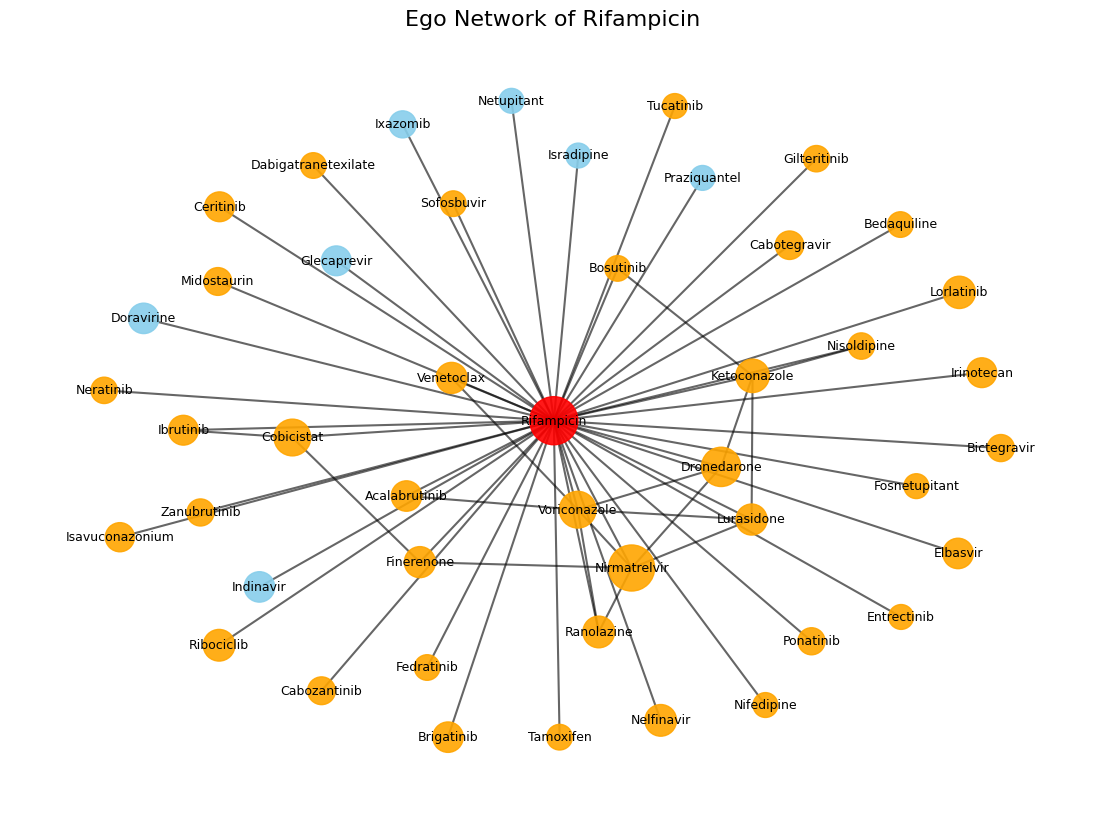

In [32]:
draw_ego_network(G, rif_code)

In [12]:
import plotly.graph_objects as go
def draw_ego_network_plotly_by_name(G, node_overlay_df, drug_name_eng):
    # -------------------------------------------------
    # 1) 중심 약물 코드 찾기
    # -------------------------------------------------
    sub = node_overlay_df[node_overlay_df["label_eng"] == drug_name_eng].copy()

    if len(sub) == 0:
        print(f"'{drug_name_eng}' not found.")
        return None

    center_code = sub.iloc[0]["code"]

    # -------------------------------------------------
    # 2) ego subgraph 만들기
    # -------------------------------------------------
    neighbors = list(G.neighbors(center_code))
    ego_nodes = [center_code] + neighbors
    ego_G = G.subgraph(ego_nodes).copy()

    # -------------------------------------------------
    # 3) layout 계산
    # -------------------------------------------------
    pos = nx.spring_layout(ego_G, seed=42, k=0.8)

    # -------------------------------------------------
    # 4) edge trace (선)
    # -------------------------------------------------
    edge_x = []
    edge_y = []

    edge_hover_x = []
    edge_hover_y = []
    edge_hover_text = []

    for u, v, data in ego_G.edges(data=True):
        x0, y0 = pos[u]
        x1, y1 = pos[v]

        edge_x.extend([x0, x1, None])
        edge_y.extend([y0, y1, None])

        # hover용 중간점
        mx = (x0 + x1) / 2
        my = (y0 + y1) / 2

        edge_hover_x.append(mx)
        edge_hover_y.append(my)

        u_name = G.nodes[u].get("label_eng", u)
        v_name = G.nodes[v].get("label_eng", v)

        edge_hover_text.append(
            f"<b>{u_name}</b> ↔ <b>{v_name}</b><br>"
            f"Reason: {data.get('reason', '-')}"
        )

    edge_trace = go.Scatter(
        x=edge_x,
        y=edge_y,
        line=dict(width=1.5, color="gray"),
        hoverinfo="none",
        mode="lines",
        showlegend=False
    )

    edge_hover_trace = go.Scatter(
        x=edge_hover_x,
        y=edge_hover_y,
        mode="markers",
        marker=dict(size=10, color="rgba(0,0,0,0)"),
        text=edge_hover_text,
        hoverinfo="text",
        showlegend=False
    )

    # -------------------------------------------------
    # 5) node trace
    # -------------------------------------------------
    node_x = []
    node_y = []
    node_text = []
    node_sizes = []
    node_colors = []
    node_labels = []

    for node in ego_G.nodes():
        x, y = pos[node]
        attr = G.nodes[node]

        node_x.append(x)
        node_y.append(y)

        is_center = (node == center_code)

        # 색상 규칙
        if is_center:
            color = "red"
        elif attr.get("is_preg_contra", False):
            color = "orange"
        elif attr.get("is_elderly_caution", False):
            color = "purple"
        elif attr.get("is_age_contra", False):
            color = "green"
        else:
            color = "skyblue"

        node_colors.append(color)

        # 크기 규칙
        size = 35 if is_center else 14 + attr.get("degree", 1) * 1.2
        node_sizes.append(size)

        label_eng = attr.get("label_eng", node)
        label_kor = attr.get("label_kor", "-")
        degree = attr.get("degree", 0)
        is_preg = attr.get("is_preg_contra", False)
        preg_grade = attr.get("preg_grade", "-")
        is_elderly = attr.get("is_elderly_caution", False)
        is_age = attr.get("is_age_contra", False)
        age_rule = attr.get("age_rule", "-")

        node_labels.append(label_eng)

        hover_text = (
            f"<b>{label_eng}</b><br>"
            f"Korean: {label_kor}<br>"
            f"Degree: {degree}<br>"
            f"Pregnancy Contraindication: {is_preg}<br>"
            f"Pregnancy Grade: {preg_grade}<br>"
            f"Elderly Caution: {is_elderly}<br>"
            f"Age Contraindication: {is_age}<br>"
            f"Age Rule: {age_rule}"
        )
        node_text.append(hover_text)

    node_trace = go.Scatter(
        x=node_x,
        y=node_y,
        mode="markers+text",
        text=node_labels,
        textposition="top center",
        hoverinfo="text",
        hovertext=node_text,
        marker=dict(
            size=node_sizes,
            color=node_colors,
            line=dict(width=1, color="black")
        ),
        showlegend=False
    )

    # -------------------------------------------------
    # 6) figure
    # -------------------------------------------------
    fig = go.Figure(data=[edge_trace, edge_hover_trace, node_trace])

    fig.update_layout(
        title=f"Interactive Ego Network of {drug_name_eng}",
        title_x=0.5,
        hovermode="closest",
        margin=dict(l=20, r=20, t=50, b=20),
        xaxis=dict(showgrid=False, zeroline=False, visible=False),
        yaxis=dict(showgrid=False, zeroline=False, visible=False),
        plot_bgcolor="white",
        paper_bgcolor="white",
        height=800
    )

    fig.show()

    return fig

In [16]:
_ = draw_ego_network_plotly_by_name(G, node_overlay_df, "Rifampicin")